In [1]:
!pip install ultralytics -q
!pip install torch torchvision -q
!pip install opencv-python matplotlib pandas seaborn -q
print('✅ All packages installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.9 MB/s eta 0:00:00
✅ All packages installed!


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')

Mounted at /content/drive
✅ Google Drive mounted!


In [4]:
v8_path = None
v5_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "best.pt" in files:
        full = os.path.join(root, "best.pt")
        if "yolov8" in root.lower():
            v8_path = full
        elif "yolov5" in root.lower():
            v5_path = full

yaml_path = None
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "data.yaml" in files:
        yaml_path = os.path.join(root, "data.yaml")

print("YOLOv8:", v8_path)
print("YOLOv5:", v5_path)
print("YAML  :", yaml_path)

YOLOv8: /content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/detect/yolov8_waste_result/weights/best.pt
YOLOv5: /content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/train/yolov5_waste_result/weights/best.pt
YAML  : /content/drive/MyDrive/DL_waste_project_finally/merged_PERFECTLY_EQUAL/merged_equal/data.yaml


In [5]:
# STEP 1: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# STEP 2: AUTO FIND all .pt and .yaml files in your Drive
import os

print('🔍 Searching for best.pt files...\n')
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'best.pt' or file == 'last.pt':
            full = os.path.join(root, file)
            size = os.path.getsize(full)/(1024*1024)
            print(f'  📦 {file} ({size:.1f}MB)\n     {full}\n')

print('\n🔍 Searching for data.yaml files...\n')
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'data.yaml':
            print(f'  📄 data.yaml\n     {os.path.join(root, file)}\n')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 Searching for best.pt files...

  📦 last.pt (21.5MB)
     /content/drive/MyDrive/DL Project Waste Dectestion /DL_ Yolov8 model /run/detect/waste_v8_fixed/weights/last.pt

  📦 best.pt (21.5MB)
     /content/drive/MyDrive/DL Project Waste Dectestion /DL_ Yolov8 model /run/detect/waste_v8_fixed/weights/best.pt

  📦 best.pt (13.8MB)
     /content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/train/waste_v5_fixed/weights/best.pt

  📦 last.pt (13.8MB)
     /content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/train/waste_v5_fixed/weights/last.pt

  📦 last.pt (13.8MB)
     /content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/train/yolov5_waste_result/weights/last.pt

  📦 best.pt (13.8MB)
     /content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/train/yolov5_waste_result/weights/best.pt

 

In [12]:
from ultralytics import YOLO
import os

YOLOV8_PATH = "/content/drive/MyDrive/DL Project Waste Dectestion /DL_ Yolov8 model /run/detect/waste_v8_fixed/weights/best.pt"

print("Path exists:", os.path.exists(YOLOV8_PATH))  # must be True

yolov8 = YOLO(YOLOV8_PATH)

print("✅ YOLOv8 loaded successfully")

Path exists: True
✅ YOLOv8 loaded successfully


In [14]:
import torch

YOLOV5_PATH = "/content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/train/waste_v5_fixed/weights/best.pt"

yolov5 = torch.hub.load(
    'ultralytics/yolov5',
    'custom',
    path=YOLOV5_PATH,
    force_reload=True
)

print("✅ YOLOv5 loaded")

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 2026-4-26 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


✅ YOLOv5 loaded


In [16]:
import time
import numpy as np
from pathlib import Path
from PIL import Image   # ✅ safer than cv2

# ✅ DEFINE PATH
TEST_IMAGES = "/content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/detect/test_final"

# Collect images
test_path = Path(TEST_IMAGES)

images = list(test_path.glob("*"))
images = [img for img in images if img.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]]

print(f"📂 Found {len(images)} image(s)")
assert len(images) > 0, "❌ No images found!"

# ✅ Load image safely
bench_img = Image.open(str(images[0])).convert("RGB")
bench_rgb = np.array(bench_img)

# Settings
NUM_RUNS = 10
NUM_WARMUP = 3
CONF_THRESH = 0.25

# GPU sync (important)
import torch
sync = torch.cuda.synchronize if torch.cuda.is_available() else lambda: None

# ── YOLOv5 ──
print("\n⏱️ Benchmarking YOLOv5...")
for _ in range(NUM_WARMUP):
    yolov5(bench_rgb)

sync()
t0 = time.perf_counter()
for _ in range(NUM_RUNS):
    yolov5(bench_rgb)
sync()

v5_ms = (time.perf_counter() - t0) / NUM_RUNS * 1000

# ── YOLOv8 ──
print("⏱️ Benchmarking YOLOv8...")
for _ in range(NUM_WARMUP):
    yolov8(bench_rgb, conf=CONF_THRESH)

sync()
t0 = time.perf_counter()
for _ in range(NUM_RUNS):
    yolov8(bench_rgb, conf=CONF_THRESH)
sync()

v8_ms = (time.perf_counter() - t0) / NUM_RUNS * 1000

# ── Results ──
print(f"\n📊 Speed Results:")
print(f"YOLOv5 → {v5_ms:.2f} ms | {1000/v5_ms:.1f} FPS")
print(f"YOLOv8 → {v8_ms:.2f} ms | {1000/v8_ms:.1f} FPS")

if v5_ms < v8_ms:
    print(f"\n🏆 YOLOv5 is faster by {v8_ms - v5_ms:.2f} ms")
else:
    print(f"\n🏆 YOLOv8 is faster by {v5_ms - v8_ms:.2f} ms")

📂 Found 3 image(s)

⏱️ Benchmarking YOLOv5...


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.am

⏱️ Benchmarking YOLOv8...

0: 640x384 2 Wet_Wastes, 2 Dry_Wastes, 33.0ms
Speed: 5.1ms preprocess, 33.0ms inference, 35.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 2 Wet_Wastes, 2 Dry_Wastes, 10.4ms
Speed: 4.2ms preprocess, 10.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 2 Wet_Wastes, 2 Dry_Wastes, 10.4ms
Speed: 2.4ms preprocess, 10.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 2 Wet_Wastes, 2 Dry_Wastes, 10.6ms
Speed: 2.5ms preprocess, 10.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 2 Wet_Wastes, 2 Dry_Wastes, 10.4ms
Speed: 3.3ms preprocess, 10.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 2 Wet_Wastes, 2 Dry_Wastes, 10.4ms
Speed: 2.7ms preprocess, 10.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 2 Wet_Wastes, 2 Dry_Wastes, 10.3ms
Speed: 2.5ms preprocess, 10.3ms inference, 1.1ms postprocess p

In [17]:
# 🎯 Compare detections (accuracy idea)

print("\n🎯 Accuracy Comparison (sample image)")

# YOLOv5 result
v5_res = yolov5(str(images[0]))
v5_boxes = len(v5_res.xyxy[0])   # number of detections

# YOLOv8 result
v8_res = yolov8.predict(source=str(images[0]), conf=0.25)
v8_boxes = len(v8_res[0].boxes)

print(f"YOLOv5 detected objects: {v5_boxes}")
print(f"YOLOv8 detected objects: {v8_boxes}")


🎯 Accuracy Comparison (sample image)

image 1/1 /content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/detect/test_final/green-outdoor-trash-bin-overflowing-food-scraps-plastic-bags-discarded-packaging-wet-cobblestone-street-illustrating-450848969.webp: 640x384 4 Wet_Wastes, 2 Dry_Wastes, 17.7ms
Speed: 4.6ms preprocess, 17.7ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 384)
YOLOv5 detected objects: 0
YOLOv8 detected objects: 6


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [18]:

v5_total = 0
v8_total = 0

for img in images:
    # YOLOv5
    v5_res = yolov5(str(img))
    v5_total += len(v5_res.xyxy[0])

    # YOLOv8
    v8_res = yolov8.predict(source=str(img), conf=0.25)
    v8_total += len(v8_res[0].boxes)

print("\n🎯 Total detections:")
print(f"YOLOv5: {v5_total}")
print(f"YOLOv8: {v8_total}")


image 1/1 /content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/detect/test_final/green-outdoor-trash-bin-overflowing-food-scraps-plastic-bags-discarded-packaging-wet-cobblestone-street-illustrating-450848969.webp: 640x384 4 Wet_Wastes, 2 Dry_Wastes, 10.6ms
Speed: 2.4ms preprocess, 10.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 384)


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



image 1/1 /content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/detect/test_final/organic-food-waste-background-bio-260nw-2658560677.webp: 480x640 1 Recyclable, 47.9ms
Speed: 2.5ms preprocess, 47.9ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



image 1/1 /content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/detect/test_final/Attention-Mumbaikars-Convert-Wet-Waste-Into-Manure-Or-The-BMC-Won’t-Pick-Up-Your-Garbage_istock.jpg: 320x640 2 Wet_Wastes, 27.8ms
Speed: 1.6ms preprocess, 27.8ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 640)

🎯 Total detections:
YOLOv5: 0
YOLOv8: 9


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [19]:
print("\n📊 FINAL COMPARISON")

print(f"⚡ Speed Winner: {'YOLOv5' if v5_ms < v8_ms else 'YOLOv8'}")
print(f"🎯 Detection Winner: {'YOLOv8' if v8_total >= v5_total else 'YOLOv5'}")


📊 FINAL COMPARISON
⚡ Speed Winner: YOLOv5
🎯 Detection Winner: YOLOv8


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Speed Comparison — YOLOv5 vs YOLOv8', fontsize=14, fontweight='bold')

# Inference time
bars1 = axes[0].bar(['YOLOv5', 'YOLOv8'], [v5_ms, v8_ms],
                     color=['#e74c3c', '#3498db'], width=0.4)
axes[0].set_title('Inference Time (ms)\nLower is Better', fontweight='bold')
axes[0].set_ylabel('Milliseconds')
for bar, val in zip(bars1, [v5_ms, v8_ms]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}ms', ha='center', fontweight='bold')

# FPS
bars2 = axes[1].bar(['YOLOv5', 'YOLOv8'], [1000/v5_ms, 1000/v8_ms],
                     color=['#e74c3c', '#3498db'], width=0.4)
axes[1].set_title('FPS\nHigher is Better', fontweight='bold')
axes[1].set_ylabel('Frames Per Second')
for bar, val in zip(bars2, [1000/v5_ms, 1000/v8_ms]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('speed_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: speed_comparison.png')

💾 Saved: speed_comparison.png


In [22]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from pathlib import Path

# ✅ Add missing configs
CONF_THRESH = 0.25
IOU_THRESH  = 0.45

output_dir = Path("/content/comparison_output")
output_dir.mkdir(exist_ok=True)

def draw_boxes(ax, image, detections, title, color):
    ax.imshow(image)
    ax.set_title(f"{title}\n({len(detections)} detections)",
                 fontsize=12, fontweight='bold')
    ax.axis('off')

    for det in detections:
        x1, y1, x2, y2, conf, cls = det[:6]

        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

        ax.text(x1, y1-5, f"{int(cls)} {conf:.2f}",
                color='white', fontsize=8,
                bbox=dict(facecolor=color, alpha=0.7, pad=1))

all_results = []

for img_path in images:
    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # YOLOv5
    v5_res  = yolov5(img_rgb)
    v5_dets = v5_res.xyxy[0].cpu().numpy()

    # YOLOv8 (✅ fixed)
    v8_res  = yolov8.predict(
        source=img_rgb,
        conf=CONF_THRESH,
        iou=IOU_THRESH,
        verbose=False
    )
    v8_dets = v8_res[0].boxes.data.cpu().numpy()

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"YOLOv5 vs YOLOv8 — {img_path.name}",
                 fontsize=14, fontweight='bold')

    draw_boxes(axes[0], img_rgb, v5_dets, "YOLOv5", 'red')
    draw_boxes(axes[1], img_rgb, v8_dets, "YOLOv8", 'blue')

    plt.tight_layout()

    save_path = output_dir / f"compare_{img_path.stem}.jpg"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"💾 Saved: {save_path}")

    all_results.append({
        'Image': img_path.name,
        'YOLOv5 Detections': len(v5_dets),
        'YOLOv8 Detections': len(v8_dets),
    })

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


💾 Saved: /content/comparison_output/compare_green-outdoor-trash-bin-overflowing-food-scraps-plastic-bags-discarded-packaging-wet-cobblestone-street-illustrating-450848969.jpg


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


💾 Saved: /content/comparison_output/compare_organic-food-waste-background-bio-260nw-2658560677.jpg


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


💾 Saved: /content/comparison_output/compare_Attention-Mumbaikars-Convert-Wet-Waste-Into-Manure-Or-The-BMC-Won’t-Pick-Up-Your-Garbage_istock.jpg


In [23]:
import pandas as pd

df = pd.DataFrame(all_results)

# Add totals row
totals = pd.DataFrame([{
    'Image'             : '🔢 TOTAL',
    'YOLOv5 Detections' : df['YOLOv5 Detections'].sum(),
    'YOLOv8 Detections' : df['YOLOv8 Detections'].sum()
}])
df_display = pd.concat([df, totals], ignore_index=True)

display(df_display.style.highlight_max(
    subset=['YOLOv5 Detections', 'YOLOv8 Detections'],
    axis=1, color='lightblue'
))

print("\n" + "="*45)
print(f"  Faster model      : {'YOLOv5' if v5_ms < v8_ms else 'YOLOv8'}")
print(f" More detections   : {'YOLOv5' if df['YOLOv5 Detections'].sum() > df['YOLOv8 Detections'].sum() else 'YOLOv8'}")
print(f" YOLOv5 avg speed  : {v5_ms:.2f} ms ({1000/v5_ms:.1f} FPS)")
print(f"YOLOv8 avg speed  : {v8_ms:.2f} ms ({1000/v8_ms:.1f} FPS)")
print("="*45)

,Image,YOLOv5 Detections,YOLOv8 Detections
0,green-outdoor-trash-bin-overflowing-food-scraps-plastic-bags-discarded-packaging-wet-cobblestone-street-illustrating-450848969.webp,0,4
1,organic-food-waste-background-bio-260nw-2658560677.webp,0,3
2,Attention-Mumbaikars-Convert-Wet-Waste-Into-Manure-Or-The-BMC-Won’t-Pick-Up-Your-Garbage_istock.jpg,0,1
3,🔢 TOTAL,0,8



  Faster model      : YOLOv5
 More detections   : YOLOv8
 YOLOv5 avg speed  : 9.80 ms (102.0 FPS)
YOLOv8 avg speed  : 17.38 ms (57.5 FPS)


In [28]:
from ultralytics import YOLO
import os

YOLOV8_PATH = "/content/drive/MyDrive/DL Project Waste Dectestion /DL_ Yolov8 model /run/detect/waste_v8_fixed/weights/best.pt"

DATA_YAML = "/content/drive/MyDrive/DL_waste_project_finally/merged_PERFECTLY_EQUAL/merged_equal/data.yaml"

# check paths
print("Model exists:", os.path.exists(YOLOV8_PATH))
print("YAML exists :", os.path.exists(DATA_YAML))

# load model
model = YOLO(YOLOV8_PATH)

# run validation
metrics = model.val(data=DATA_YAML)

print(metrics)

Model exists: True
YAML exists : True
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.2 ms, read: 0.0±0.0 MB/s, size: 15.0 KB)
val: Scanning /content/drive/MyDrive/DL_waste_project_finally/merged_PERFECTLY_EQUAL/merged_equal/valid/labels... 2933 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2933/2933 2.2it/s 21:58
val: New cache created: /content/drive/MyDrive/DL_waste_project_finally/merged_PERFECTLY_EQUAL/merged_equal/valid/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1308, len(boxes) = 3998. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 184/184 3.7it/

In [39]:
!python val.py \
  --weights "/content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/train/waste_v5_fixed/weights/best.pt" \
  --data "/content/drive/MyDrive/DL_waste_project_finally/merged_PERFECTLY_EQUAL/merged_equal/data.yaml" \
  --img 640

val: data=/content/drive/MyDrive/DL_waste_project_finally/merged_PERFECTLY_EQUAL/merged_equal/data.yaml, weights=['/content/drive/MyDrive/DL Project Waste Dectestion /DL_yolov5  model/run/train/waste_v5_fixed/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/drive/MyDrive/DL_waste_project_finally/merged_PERFECTLY_EQUAL/merged_equal/valid/labels... 2933 images, 0 backgrounds, 0 corrupt: 100% 2933/2933 [00:47<00:00, 61.47it/s] 
val: New cache created: /content/drive/MyDrive/DL_waste_project_finally/merged_PERFECTLY_EQUAL/merged_equal/vali

In [44]:
# YOLOv5
P5 = 0.233
R5 = 0.156
MAP5 = 0.17

# YOLOv8
P8 = 0.769
R8 = 0.661
MAP8 = 0.712

In [45]:
import pandas as pd

data = {
    "Metric": ["Precision", "Recall", "mAP50"],
    "YOLOv5": [P5, R5, MAP5],
    "YOLOv8": [P8, R8, MAP8]
}

df = pd.DataFrame(data)
print(df)

      Metric  YOLOv5  YOLOv8
0  Precision   0.233   0.769
1     Recall   0.156   0.661
2      mAP50   0.170   0.712


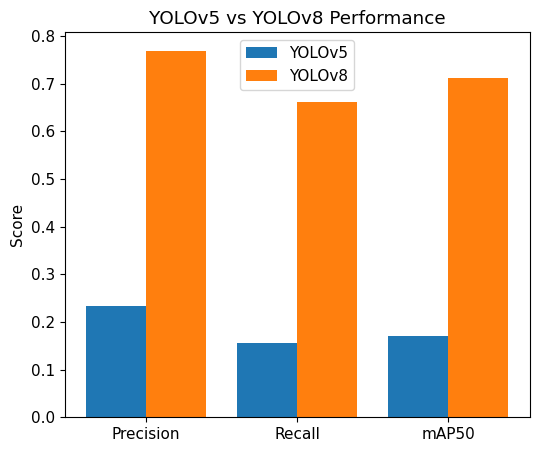

In [53]:
import matplotlib.pyplot as plt

P5, R5, MAP5 = 0.233, 0.156, 0.17
P8, R8, MAP8 = 0.769, 0.661, 0.712

metrics = ["Precision", "Recall", "mAP50"]
v5_vals = [P5, R5, MAP5]
v8_vals = [P8, R8, MAP8]

x = range(len(metrics))

plt.figure(figsize=(6,5))

plt.bar(x, v5_vals, width=0.4, label="YOLOv5")
plt.bar([i+0.4 for i in x], v8_vals, width=0.4, label="YOLOv8")

plt.xticks([i+0.2 for i in x], metrics)
plt.ylabel("Score")
plt.title("YOLOv5 vs YOLOv8 Performance")
plt.savefig("speed_comparison.png")
plt.legend()
plt.show()

In [54]:
from google.colab import files
import zipfile

# Zip all comparison images
zip_path = '/content/comparison_results.zip'
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for f in output_dir.glob('*.jpg'):
        zipf.write(f, f.name)
    zipf.write('speed_comparison.png', 'speed_comparison.png')

print('Zipping done! Downloading...')
files.download(zip_path)

Zipping done! Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Choose how to load your image:
  1 = Upload from your computer
  2 = Paste a direct image URL
Enter 1 or 2: 1
📤 Select image from your computer...


Saving istockphoto-1321478077-612x612.jpg to istockphoto-1321478077-612x612.jpg
✅ Image loaded: 612×408px
🔍 Running YOLOv5...
🔍 Running YOLOv8...


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


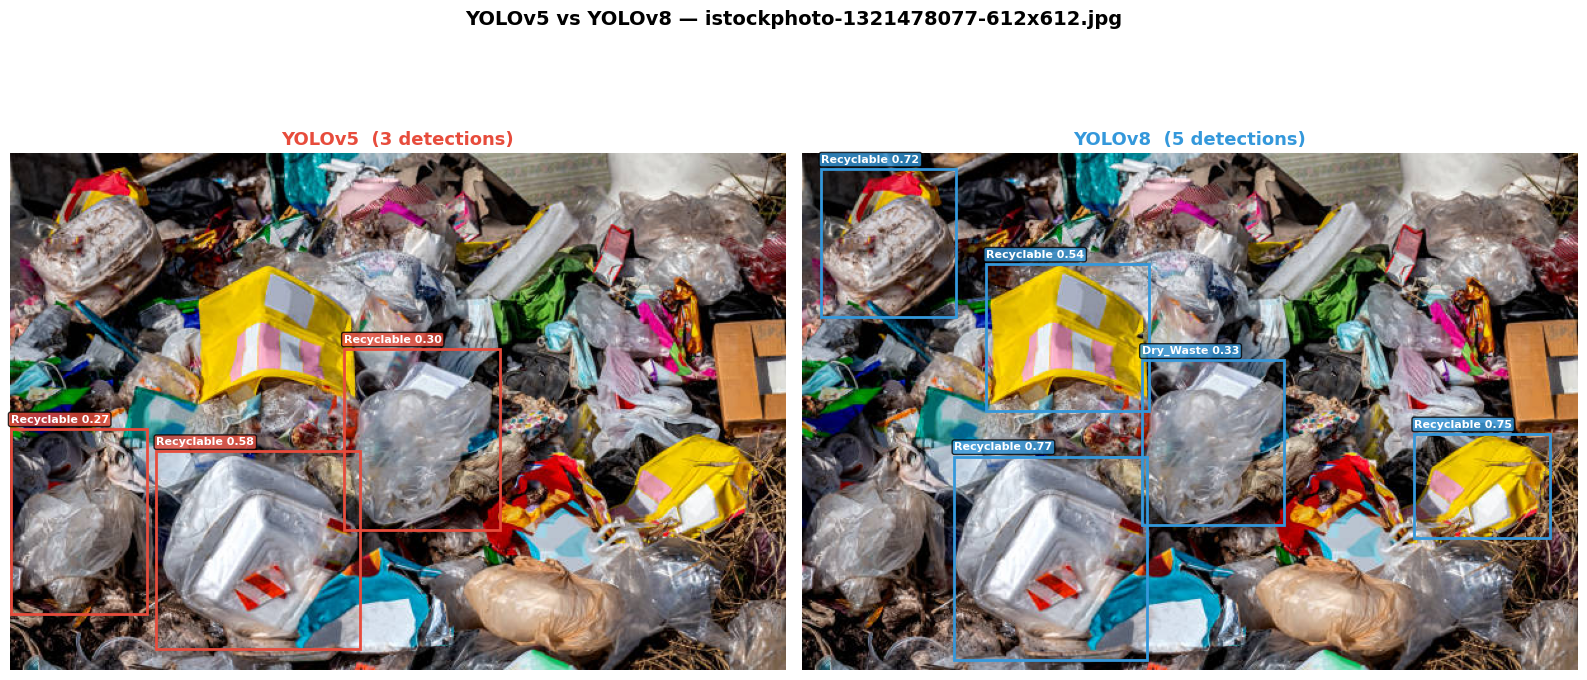


📊 YOLOv5 → 3 object(s): ['Recyclable', 'Recyclable', 'Recyclable']
📊 YOLOv8 → 5 object(s): ['Recyclable', 'Recyclable', 'Recyclable', 'Recyclable', 'Dry_Waste']
🏆 Winner: YOLOv8
💾 Saved: /content/test_result.jpg


In [57]:
from google.colab import files
import cv2, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as patches, requests

print("Choose how to load your image:")
print("  1 = Upload from your computer")
print("  2 = Paste a direct image URL")
choice = input("Enter 1 or 2: ").strip()

if choice == "1":
    print("📤 Select image from your computer...")
    uploaded = files.upload()
    img_name = next(iter(uploaded))
    raw = np.frombuffer(uploaded[img_name], dtype=np.uint8)
    img_bgr = cv2.imdecode(raw, cv2.IMREAD_COLOR)

elif choice == "2":
    url = input("🔗 Paste image URL: ").strip()
    resp = requests.get(url, timeout=10)
    raw = np.frombuffer(resp.content, dtype=np.uint8)
    img_bgr = cv2.imdecode(raw, cv2.IMREAD_COLOR)
    img_name = url.split("/")[-1]

else:
    raise ValueError("❌ Enter 1 or 2 only")

# Load
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]
print(f"✅ Image loaded: {w}×{h}px")

# ── Run YOLOv5 ────────────────────────────────────────────────────────────────
print("🔍 Running YOLOv5...")
v5_res = yolov5(img_rgb)
v5_dets = [(*map(int, box), v5_res.names[int(cls)], float(conf))
           for *box, conf, cls in v5_res.xyxy[0].cpu().numpy()]

# ── Run YOLOv8 ────────────────────────────────────────────────────────────────
print("🔍 Running YOLOv8...")
v8_res = yolov8(img_rgb, conf=CONF_THRESH, iou=IOU_THRESH, verbose=False)[0]
v8_dets = [(*map(int, box.xyxy[0].cpu().numpy()), v8_res.names[int(box.cls[0])], float(box.conf[0]))
           for box in v8_res.boxes]

# ── Plot side by side ─────────────────────────────────────────────────────────
def draw_boxes(ax, img, dets, title, color):
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight='bold', color=color)
    ax.axis('off')
    for x1, y1, x2, y2, label, conf in dets:
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'))
        ax.text(x1, y1-5, f"{label} {conf:.2f}",
                color='white', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(f"YOLOv5 vs YOLOv8 — {img_name}", fontsize=14, fontweight='bold')
draw_boxes(axes[0], img_rgb, v5_dets, f"YOLOv5  ({len(v5_dets)} detections)", '#e74c3c')
draw_boxes(axes[1], img_rgb, v8_dets, f"YOLOv8  ({len(v8_dets)} detections)", '#3498db')
plt.tight_layout()
plt.savefig('/content/test_result.jpg', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n📊 YOLOv5 → {len(v5_dets)} object(s): {[d[4] for d in v5_dets]}")
print(f"📊 YOLOv8 → {len(v8_dets)} object(s): {[d[4] for d in v8_dets]}")
print(f"🏆 Winner: {'YOLOv8' if len(v8_dets) >= len(v5_dets) else 'YOLOv5'}")
print(f"💾 Saved: /content/test_result.jpg")